# 重現性設定

In [1]:
import os
import numpy as np
import random
import tensorflow as tf

# 設定環境變數
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# 設定執行緒
try:
    tf.config.threading.set_inter_op_parallelism_threads(1)
    tf.config.threading.set_intra_op_parallelism_threads(1)
except RuntimeError as e:
    print(f"警告：設定失敗，原因可能是環境已初始化。{e}")

# 設定所有隨機種子
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("環境配置完成！")

環境配置完成！


# 載入資料集與預處理

In [2]:
from tensorflow.keras.datasets import cifar10

(X_train_image, y_train_label), (X_test_image, y_test_label) = cifar10.load_data()

# reshape 轉成1維
y_train_label = y_train_label.reshape(-1)
y_test_label = y_test_label.reshape(-1)

# 進行標準化
X_train_normalize = X_train_image.astype('float32') / 255.0
X_test_normalize = X_test_image.astype('float32') / 255.0

# One-hot Encoding處理
from tensorflow.keras import utils

y_train_onehot = utils.to_categorical(y_train_label)
y_test_onehot = utils.to_categorical(y_test_label)

print('Train Data images:',X_train_normalize.shape)
print('Train Data labels:',y_train_onehot.shape)
print('Test Data images:',X_test_normalize.shape)
print('Test Data labels:',y_test_onehot.shape)

Train Data images: (50000, 32, 32, 3)
Train Data labels: (50000, 10)
Test Data images: (10000, 32, 32, 3)
Test Data labels: (10000, 10)


# 建立模型

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense

model = Sequential()

# 卷積層
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    padding='same',
    input_shape=(32, 32, 3),
    activation='relu'))
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    padding='same',
    activation='relu'))
# 池化層
model.add(MaxPooling2D(pool_size=(2,2)))

# 卷積層
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    padding='same',
    activation='relu'))
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    padding='same',
    activation='relu'))
# 池化層
model.add(MaxPooling2D(pool_size=(2,2)))

# 卷積層
model.add(Conv2D(
    filters=128,
    kernel_size=(3,3),
    padding='same',
    activation='relu'))
model.add(Conv2D(
    filters=128,
    kernel_size=(3,3),
    padding='same',
    activation='relu'))
# 池化層
model.add(MaxPooling2D(pool_size=(2,2)))

# 平坦層
model.add(Flatten())
# 隱藏層
model.add(Dense(128, activation='relu'))
# 輸出層
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

# 函數建立模型

In [4]:
# 加入regularization
from tensorflow.keras.regularizers import l2
reg = l2(0.002)

def build_model(model, p_bname, p_conv, p_filters, p_drop_rate): # model, block名稱, 卷積層數量, 卷積層參數數量, 卷積層參數大小, 丟棄層
    for i in range(p_conv):
        model.add(Conv2D(
            filters=p_filters,
            kernel_size=(3, 3),
            activation='relu',
            padding='same',
            kernel_regularizer=reg, # weight Regularization
            bias_regularizer=reg, # bias Regularization
            name=p_bname + '_conv' + str(i + 1)
        ))

    model.add(MaxPooling2D(pool_size=(2, 2), name=p_bname + '_pool'))

    if p_drop_rate > 0:
        model.add(Dropout(p_drop_rate, name=p_bname + '_Dr'))

In [5]:
drop_rate = 0.5
model = Sequential()
model.add(Input(shape=(32, 32, 3)))
build_model(model, p_bname='block1', p_conv=2, p_filters=32, p_drop_rate=drop_rate)
build_model(model, p_bname='block2', p_conv=2, p_filters=64, p_drop_rate=drop_rate)
build_model(model, p_bname='block3', p_conv=2, p_filters=128, p_drop_rate=drop_rate)

model.add(Flatten())
model.add(Dense(128, activation='relu', kernel_regularizer=reg, bias_regularizer=reg))
model.add(Dense(10, activation='softmax', kernel_regularizer=reg, bias_regularizer=reg))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_Dr (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_Dr (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_Dr (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
DISPLAY_LAYER = 4
# 取得前 4 層的輸出
output_layers = [layer.output for layer in model.layers[:DISPLAY_LAYER]]
output_layers

[<KerasTensor shape=(None, 32, 32, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_80>,
 <KerasTensor shape=(None, 32, 32, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_82>,
 <KerasTensor shape=(None, 16, 16, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_85>,
 <KerasTensor shape=(None, 16, 16, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_89>]

In [7]:
from tensorflow.keras import models

DISPLAY_LAYER = 4
output_layers = [layer.output for layer in model.layers[:DISPLAY_LAYER]]

feature_map_model = models.Model(
    inputs=model.inputs,
    outputs=output_layers
)

feature_map_model.summary()

Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 32, 32,    │        896 │ input_layer_1[0]… │
│ (Conv2D)            │ 32)               │            │ input_layer_1[0]… │
│                     │                   │            │ input_layer_1[0]… │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 32, 32,    │      9,248 │ block1_conv1[1][… │
│ (Conv2D)            │ 32)               │            │ block1_conv1[2][… │
│                     │                   │            │ block1_conv1[3][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 16, 16,    │          0 │ block1_conv2[1][… │
│ (MaxPooling2D)      │ 32)               │            │ block1_conv2[2][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_Dr (Dropout) │ (None, 16, 16,    │          0 │ block1_pool[1][0] │
│                     │ 32)               │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,144 (39.62 KB)

 Trainable params: 10,144 (39.62 KB)

 Non-trainable params: 0 (0.00 B)

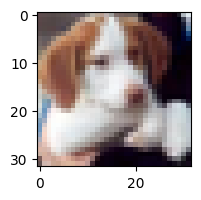

In [8]:
import matplotlib.pyplot as plt

def plot_image(image, img_size=1):
  fig = plt.gcf()
  fig.set_size_inches(2,2)
  plt.imshow(image, cmap='binary')
  plt.show()

IMG_ID = 16
plot_image(X_test_image[IMG_ID])

In [9]:
X_test_image[IMG_ID].shape

(32, 32, 3)

In [10]:
# 轉為4維並做標準化處理
input_4d_img = (X_test_image[IMG_ID].reshape(-1, 32, 32, 3).astype('float32')) / 255
input_4d_img.shape

(1, 32, 32, 3)

In [11]:
feature_maps = feature_map_model.predict(input_4d_img)

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['acc'])

train_history = model.fit(
    x=X_train_normalize,
    y=y_train_onehot,
    validation_split=0.2,
    epochs=10,
    batch_size=200,
    verbose=2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step
Epoch 1/10
200/200 - 14s - 68ms/step - acc: 0.2656 - loss: 2.3240 - val_acc: 0.3792 - val_loss: 1.8537
Epoch 2/10
200/200 - 6s - 32ms/step - acc: 0.3892 - loss: 1.7979 - val_acc: 0.4516 - val_loss: 1.6801
Epoch 3/10
200/200 - 6s - 32ms/step - acc: 0.4480 - loss: 1.6697 - val_acc: 0.4897 - val_loss: 1.5726
Epoch 4/10
200/200 - 7s - 33ms/step - acc: 0.4791 - loss: 1.5945 - val_acc: 0.5219 - val_loss: 1.5110
Epoch 5/10
200/200 - 6s - 32ms/step - acc: 0.5063 - loss: 1.5450 - val_acc: 0.5564 - val_loss: 1.4421
Epoch 6/10
200/200 - 6s - 32ms/step - acc: 0.5206 - loss: 1.5145 - val_acc: 0.5612 - val_loss: 1.4326
Epoch 7/10
200/200 - 6s - 32ms/step - acc: 0.5353 - loss: 1.4835 - val_acc: 0.5712 - val_loss: 1.3929
Epoch 8/10
200/200 - 7s - 33ms/step - acc: 0.5456 - loss: 1.4590 - val_acc: 0.5788 - val_loss: 1.3846
Epoch 9/10
200/200 - 6s - 32ms/step - acc: 0.5544 - loss: 1.4458 - val_acc: 0.5910 - val_loss: 1.3489
Epoch 10/10
200/200 - 7s - 33ms/step - acc

# 圖形顯示過程

In [12]:
import matplotlib.pyplot as plt

def show_train_history(train_history, train_key, validation_key):
    plt.plot(train_history.history[train_key], '--')
    plt.plot(train_history.history[validation_key])
    plt.title('Train History')
    plt.ylabel(train_key)
    plt.xlabel('Epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

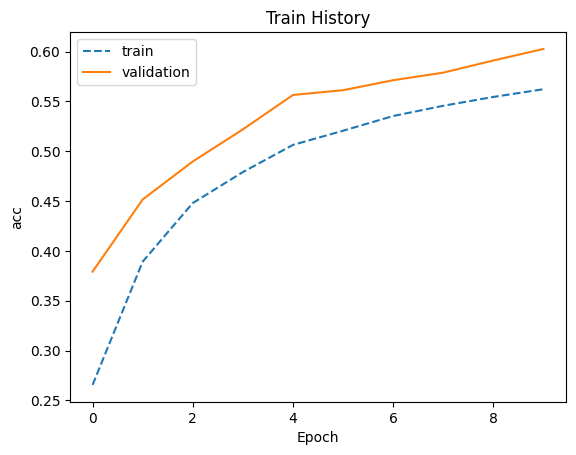

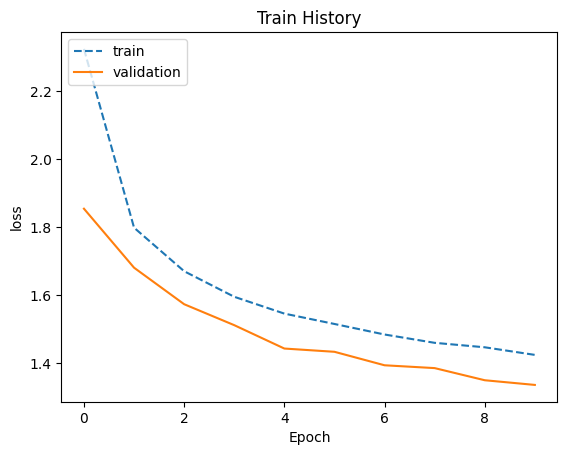

In [13]:
show_train_history(train_history, 'acc', 'val_acc')
show_train_history(train_history, 'loss', 'val_loss')

# 測試模型

In [14]:
scores = model.evaluate(X_test_normalize, y_test_onehot, verbose=2)
print('Test Accuracy:', scores[1])
print('Test Loss:', scores[0])

313/313 - 2s - 5ms/step - acc: 0.5964 - loss: 1.3373
Test Accuracy: 0.5964000225067139
Test Loss: 1.337296485900879


In [15]:
feature_maps_trained = feature_map_model.predict(input_4d_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


In [16]:
# 顯示各層名稱
layer_names = []
for layer in feature_map_model.layers:
  layer_names.append(layer.name)
  print(layer.name)

input_layer_1
block1_conv1
block1_conv2
block1_pool
block1_Dr


In [17]:
# 顯示各層形狀
print(len(feature_maps))
for i in range(len(feature_maps)):
  print('layer', i, ' ', layer_names[i], ':', feature_maps[i].shape)

4
layer 0   input_layer_1 : (1, 32, 32, 32)
layer 1   block1_conv1 : (1, 32, 32, 32)
layer 2   block1_conv2 : (1, 16, 16, 32)
layer 3   block1_pool : (1, 16, 16, 32)


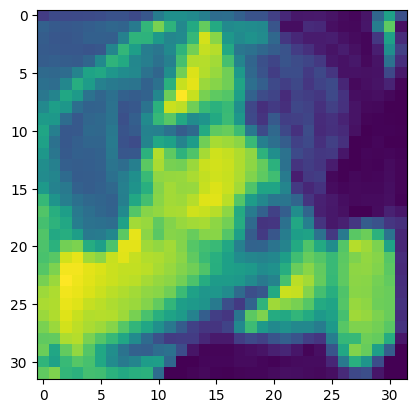

In [18]:
plt.imshow(feature_maps[0][0, :, :, 0], cmap='viridis')
plt.show()

# 顯示全部特徵圖

In [19]:
import math

def display_feature_maps(feature_maps, layer_names, idx, fig_width=18, n_cols=16, p_cmap='viridis'):
    print('layer', idx, layer_names[idx], feature_maps[idx].shape)

    n_feature_maps = feature_maps[idx].shape[3]
    n_rows = math.ceil(n_feature_maps / n_cols)

    fig = plt.gcf()
    fig.set_size_inches(fig_width, n_rows * 1.2)

    for i in range(n_feature_maps):
        ax = plt.subplot(n_rows, n_cols, i + 1)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.imshow(feature_maps[idx][0, :, :, i], cmap=p_cmap)

    plt.show()

layer 0 input_layer_1 (1, 32, 32, 32)


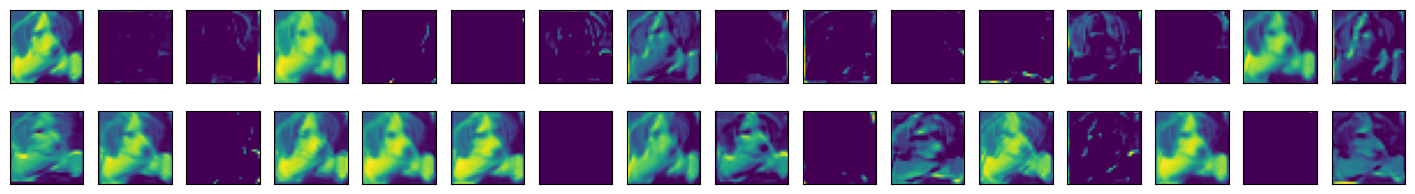

In [20]:
display_feature_maps(feature_maps, layer_names, idx=0)

# 訓練前後比較

layer 0 input_layer_1 (1, 32, 32, 32)


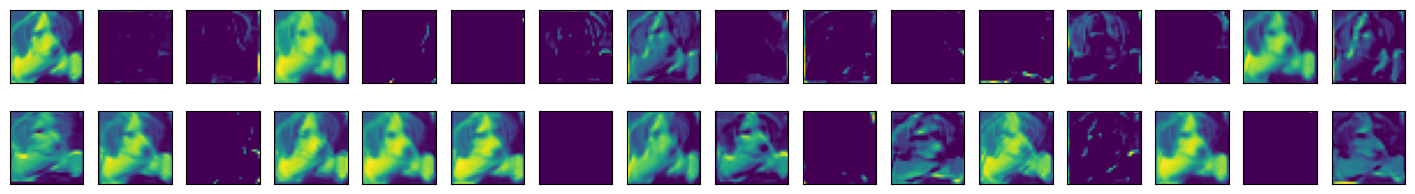

In [21]:
# 訓練前
# 顯示第0層(卷積層1)的特徵圖
display_feature_maps(feature_maps=feature_maps, layer_names=layer_names, idx=0)

layer 0 input_layer_1 (1, 32, 32, 32)


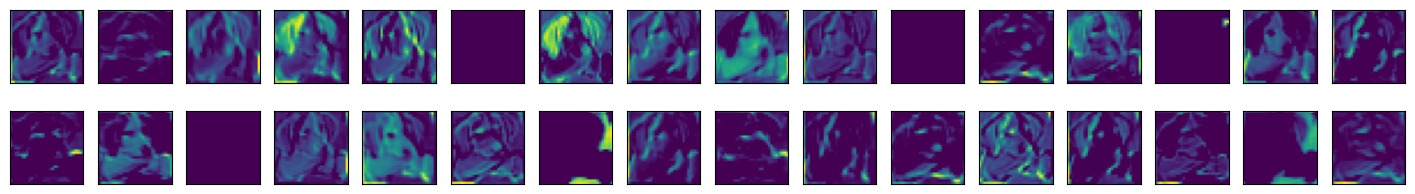

In [22]:
# 訓練後
# 顯示第0層(卷積層1)的特徵圖
display_feature_maps(feature_maps=feature_maps_trained, layer_names=layer_names, idx=0)

*   訓練前無法提取輪廓
*   訓練後可提取輪廓、邊緣、形狀

layer 1 block1_conv1 (1, 32, 32, 32)


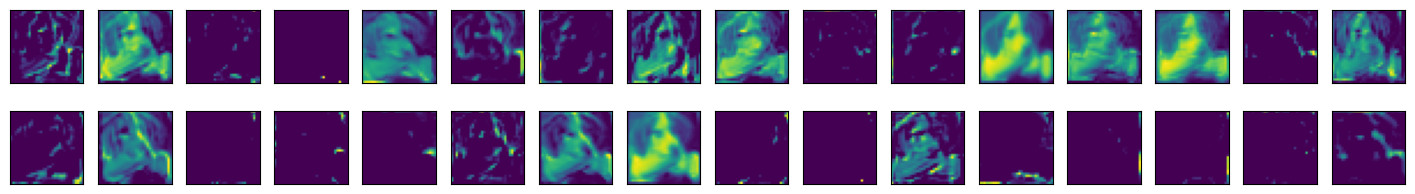

layer 1 block1_conv1 (1, 32, 32, 32)


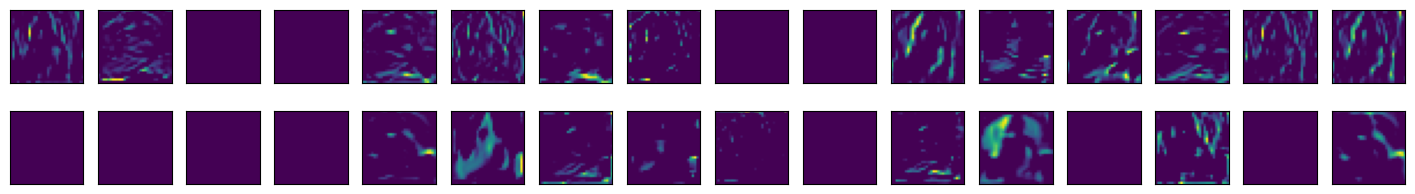

In [23]:
# 訓練前
# 顯示第1層(池化層1)的特徵圖
display_feature_maps(feature_maps=feature_maps, layer_names=layer_names, idx=1)

# 訓練後
# 顯示第1層(池化層1)的特徵圖
display_feature_maps(feature_maps=feature_maps_trained, layer_names=layer_names, idx=1)

layer 2 block1_conv2 (1, 16, 16, 32)


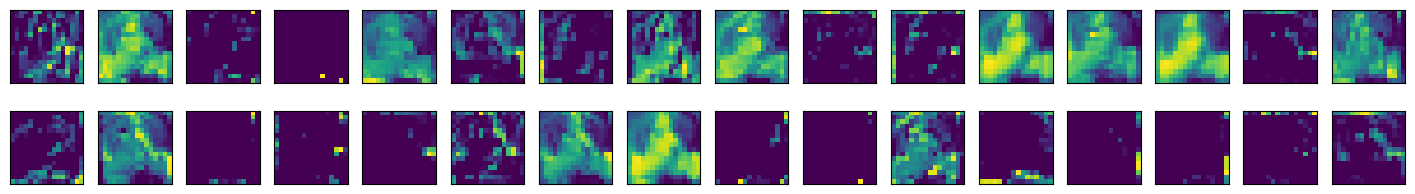

layer 2 block1_conv2 (1, 16, 16, 32)


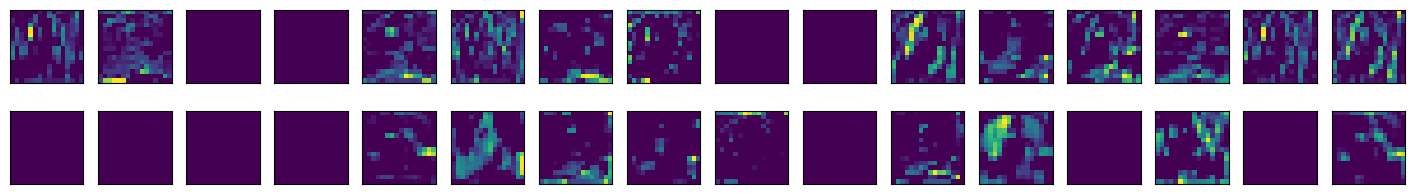

In [24]:
# 訓練前
# 顯示第3層(卷積層2)的特徵圖
display_feature_maps(feature_maps=feature_maps, layer_names=layer_names, idx=2)

# 訓練後
# 顯示第3層(卷積層2)的特徵圖
display_feature_maps(feature_maps=feature_maps_trained, layer_names=layer_names, idx=2)

layer 3 block1_pool (1, 16, 16, 32)


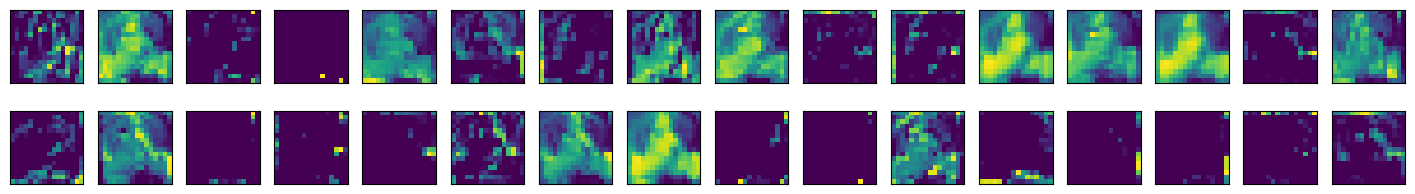

layer 3 block1_pool (1, 16, 16, 32)


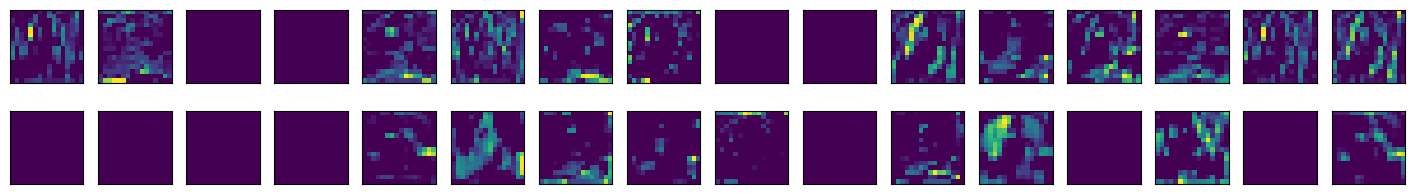

In [25]:
# 訓練前
# 顯示第4層(池化層2)的特徵圖
display_feature_maps(feature_maps=feature_maps, layer_names=layer_names, idx=3)

# 訓練後
# 顯示第4層(池化層2)的特徵圖
display_feature_maps(feature_maps=feature_maps_trained, layer_names=layer_names, idx=3)